In [2]:
import pandas as pd
import numpy as np
import geopy.distance # pip install geopy library
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



In [3]:
warnings.filterwarnings("ignore", category=FutureWarning) # Ignore warnings

airline_df = pd.read_excel('../data/AirportPassengers.xlsx') # passengers count
visitors_df = pd.read_excel('../data/InternationalVisitors.xlsx')
# House Price - ALL cities 
zillow_df = pd.read_csv('../data/Zillow_Value_AllCities.csv')  # https://www.zillow.com/research/data/ 

#Population
bos_pop_df = pd.read_csv("../data/BOS_population.csv") # https://data.boston.gov/dataset/2020-census-for-boston/resource/5800a0a2-6acd-41a3-9fe0-1bf7b038750d
den_pop_df = pd.read_csv("../data/DEN_population.csv") # https://catalog.data.gov/dataset/2010-census-populations-by-zip-code
lax_pop_df = pd.read_csv("../data/LAX_population.csv") # https://data.lacounty.gov/datasets/lacounty::2020-census-blocks/about?layer=3
nyc_pop_df = pd.read_csv("../data/NYC_population.csv") # https://catalog.data.gov/dataset/new-york-city-population-by-neighborhood-tabulation-areas



#Rename columns for population data for neighbourhood
bos_pop_df = bos_pop_df.rename(columns={"tract20_nbhd": "neighbourhood", "P0020001": "population" })
den_pop_df = den_pop_df.rename(columns={"NAME": "neighbourhood", "SUM_POPULATION_2010": "population" })
nyc_pop_df = nyc_pop_df.rename(columns={"NTA Name": "neighbourhood", "Population": "population" })
lax_pop_df = lax_pop_df.rename(columns={"COMM": "neighbourhood", "POP20": "population" })

#Rename column for airport arrival passengers and international visitors
airline_df = airline_df.rename(columns={"DEST": "airport_code", "PASSENGERS": "passengers" })
visitors_df = visitors_df.rename(columns={"U.S. MSAs Visited": "city", "Expanded Estimates": "visitors" })

# Airbnb Listing for Short and Long Term Rental https://insideairbnb.com/get-the-data/
bos_df = pd.read_csv("../data/BOS_Listings.csv")
den_df = pd.read_csv("../data/DEN_Listings.csv")
lax_df = pd.read_csv("../data/LAX_Listings.csv")
nyc_df = pd.read_csv("../data/NYC_Listings.csv")



In [4]:
# Define metadata and date columns
house_price_df = zillow_df
columns = ['RegionName',
           'State', 'City']
date_columns = [col for col in house_price_df.columns if col not in columns]

# Reshape from wide to long format
house_price_df = pd.melt(
    house_price_df,
    id_vars=columns,
    value_vars=date_columns,
    var_name='Date',
    value_name='house_value'
)

house_price_df['Date'] = pd.to_datetime(house_price_df['Date'], errors='coerce', infer_datetime_format=True)
house_price_df = house_price_df.dropna(subset=['Date'])
most_recent_date = house_price_df['Date'].max()
house_price_df = house_price_df[house_price_df['Date'] == most_recent_date]
#house_price_df['house_value'] = house_price_df['house_value'].apply(lambda x: f"{x:,.2f}")
house_price_df['house_value'] = house_price_df['house_value'].fillna(0).astype(int)
#house_price_df = house_price_df[house_price_df["RegionName"] == "East Colfax"]
#house_price_df = house_price_df.drop(columns=columns)
print(house_price_df.head())
print(house_price_df['house_value'].dtype)


                RegionName State         City       Date  house_value
7343440           Maryvale    AZ      Phoenix 2025-02-28       337671
7343441           Paradise    NV    Las Vegas 2025-02-28       440713
7343442    Upper West Side    NY     New York 2025-02-28      2954627
7343443    Upper East Side    NY     New York 2025-02-28      4636830
7343444  South Los Angeles    CA  Los Angeles 2025-02-28       694794
int64


In [5]:
# Merge and rank cities based on airport passenger volume and international visitors
# Step 2: Process airport and fare data
# airline_df['city'] = airline_df['city'].apply(lambda x: x.split(',')[0].strip())
# airline_df = airline_df.groupby('city')['passengers'].sum().reset_index()

# Step 3: Process international visitors data 
# get city from first column
# visitors_df['city'] = visitors_df['city'].apply(lambda x: x.split(',')[0].strip())
# visitors_df = visitors_df.groupby('city')['visitors'].sum().reset_index()
# 
# print(visitors_df)
# df = df.merge(pass_vol_df[['airport_code', 'passengers']], on='airport_code',  how='left')
# df = df.merge(visitors_df[['city','visitors']], left_on='airport_city', right_on='city')
    



In [53]:
def add_city(listing_df, pop_df, pass_vol_df, visitors_df, airport_city, airport_code, airport_coords):
    air_location = tuple(airport_coords)
    df  = listing_df
    
    # Step 1: Clean and filter listings
    columns_to_drop_initial = ['name', 'license', 'host_name', 'id', 'host_id', 'calculated_host_listings_count']
    long_stay_threshold = 14 
    no_review_threshold = 10

    #df = df.drop(columns=columns_to_drop_initial).dropna()
    # Commented to analyze more neighbourhoods
    # df = df.drop(columns=columns_to_drop_initial, errors='ignore').dropna(subset=['latitude', 'longitude'])
    # popular_neighbourhoods = (
    #     df['neighbourhood'].value_counts()[lambda x: x > 100].index
    # )
    # df = df[df['neighbourhood'].isin(popular_neighbourhoods)]
    
    # Commented to get all reviews     
    # df = df[df['last_review'] > '2024-01-01']
    # df = df[df['number_of_reviews_ltm'] > no_review_threshold]
    # df = df.reset_index(drop=True)


    df['long_stay'] = np.where(df['minimum_nights'] > long_stay_threshold, 1, 0)
    df['airport_city'] = airport_city
    df['airport_code'] = airport_code

    # airport_data = pd.merge(passenger_count, fares_df, left_on='ORIGIN', right_on='Airport Code')
    # airport_data = airport_data[['Airport Code','Airport Name','City Name','State Name', 'PASSENGERS', 'Average Fare ($)']] 
    # airport_data.columns = ['airport_code','airport_name', 'airport_city', 'airport_state','passenger_count','average_fare']

    # Step 3: Calculate distance from airport
    def calculate_distance(row):
        listing_location = (row['latitude'], row['longitude'])
        return geopy.distance.geodesic(air_location, listing_location).miles
    
    df['distance_from_airport'] = df.apply(calculate_distance, axis=1)

    # Merge population data 
    df = df.merge(pop_df[['neighbourhood', 'population']], on='neighbourhood', how='left')
    # Merge Airport Passengers Volume

  # Step 2: Process airport and fare data
    pass_vol_df = pass_vol_df[pass_vol_df['airport_code'] == airport_code]
    pass_vol_df = pass_vol_df.groupby('airport_code')['passengers'].sum().reset_index()
    
  # Step 3: Process international visitors data 
    # get city from first column
    visitors_df['city'] = visitors_df['city'].apply(lambda x: x.split('-')[0].strip())

    visitors_df = visitors_df[visitors_df['city'] == airport_city]
    visitors_df = visitors_df.groupby('city')['visitors'].sum().reset_index()

    df = df.merge(pass_vol_df[['airport_code', 'passengers']], on='airport_code',  how='left')
    df = df.merge(visitors_df[['city','visitors']], left_on='airport_city', right_on='city')
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in df.columns]
    
    df_listings = df.drop(columns=columns_to_drop)

    # Step 5: Merge with Zillow data
    neighbourhood = df_listings.merge(house_price_df, how='left', left_on=['neighbourhood','airport_city'], right_on=['RegionName','City'])


    # 🔍 Debug print to help verify house_value is present
    #print("Columns after Zillow merge:", neighbourhood.columns.tolist())
    # Step 6: Drop columns if they exist
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in neighbourhood.columns]
    df = neighbourhood.drop(columns=columns_to_drop)

    
    
    # Replace NaN and None to 0
    df['population'] = df['population'].fillna(0).astype(int)
    df['house_value'] = df['house_value'].fillna(0)

# Create long_stay and short_stay as separate binary columns
    df["long_stay"] = (df["long_stay"] == 1).astype(int)
    df["short_stay"] = (df["long_stay"] == 0).astype(int)

    
    # Step 7: Group and aggregate
    agg_dict = {
        'price': 'mean',
        'availability_365': 'mean',
        'minimum_nights': 'mean',
        'long_stay': 'sum',
        'short_stay': 'sum',
        'reviews_per_month': 'mean',
        'number_of_reviews_ltm': ['mean', 'sum'],
        'distance_from_airport': 'mean',
        'population': 'mean',
        'house_value': 'mean',
        'neighbourhood': 'count',
        'passengers': 'mean',
        'visitors': 'mean',
        'airport_code': 'first'
    }

    if 'house_value' in df.columns:
        agg_dict['house_value'] = 'first'

    df_listings_group = df.groupby(['neighbourhood']).agg(agg_dict).rename(
        columns={'neighbourhood': 'neighbourhood_count'}).reset_index()
    print(df_listings_group)
    return df_listings_group


In [55]:
BOS = add_city(bos_df, bos_pop_df, airline_df, visitors_df, 'Boston', 'BOS', (42.36429977,	-71.00520325))

DEN = add_city(den_df, den_pop_df, airline_df, visitors_df, 'Denver', 'DEN', (39.8561, -104.6737))
LAX = add_city(lax_df, lax_pop_df, airline_df, visitors_df, 'Los Angeles', 'LAX', (33.9416, -118.4085))
NYC = add_city(nyc_df, nyc_pop_df, airline_df, visitors_df, 'New York', 'LGA', (40.7769, -73.8740))

combined_df = pd.concat([BOS, DEN, LAX, NYC], ignore_index=True)
combined_df = combined_df.convert_dtypes()
int_cols = [
    'availability_365', 'minimum_nights',
    'reviews_per_month', 'number_of_reviews_ltm', 
    'population', 'house_value',
    'passengers', 'visitors'
]
for col in int_cols:
    combined_df[col] = combined_df[col].fillna(0).astype(int)

numeric_cols = combined_df.select_dtypes(include=['number']).columns
# Round numeric columns to 2 decimal places
combined_df[numeric_cols] = combined_df[numeric_cols].round(2)
    
print(combined_df)
combined_df.to_csv("../data/final_dataset.csv", index=False)

              neighbourhood       price availability_365 minimum_nights  \
                                   mean             mean           mean   
0                   Allston  131.816794       191.628019      48.898551   
1                  Back Bay  243.529412       197.032070      24.967930   
2               Bay Village  348.241379       226.080000      11.320000   
3               Beacon Hill  148.192118       131.536797      29.640693   
4                  Brighton  150.062802       179.874214      35.927673   
5               Charlestown  277.876923       166.797619      25.404762   
6                 Chinatown  526.487805       239.513158      39.171053   
7                Dorchester  141.784431       202.394198      29.576792   
8                  Downtown  253.264706       222.200000      21.044706   
9               East Boston  162.867470       180.465517      25.616379   
10                   Fenway  236.427083       192.458498      27.936759   
11                Hyde Pa

In [56]:
# Individual Analysis goes here 

# Split the data into 80% training and 20% test sets
df = pd.read_csv('../data/final_dataset.csv')

sample = np.random.choice(df.index, size=int(np.ceil(0.80 * len(combined_df))), replace=False)
train_house_data = df.loc[sample]
test_house_data = df.drop(sample)

# Remove row names (reset index)
train_house_data = train_house_data.reset_index(drop=True)
test_house_data = test_house_data.reset_index(drop=True)

# Print the first 5 rows of both datasets
print("First 5 rows of the training set:")
print(train_house_data.head())

print("\nFirst 5 rows of the test set:")
print(test_house_data.head())

First 5 rows of the training set:
          neighbourhood   price availability_365 minimum_nights long_stay  \
0               Tremont   120.3              206             31        15   
1               Melrose  105.47              184             20        13   
2         Crown Heights  180.37              155             30      1047   
3               Skyland  212.67              172             11        14   
4  Washington Park West  148.44              169             12        28   

  short_stay reviews_per_month number_of_reviews_ltm number_of_reviews_ltm.1  \
0          1                 0                     0                       2   
1          7                 1                    11                     220   
2        137                 0                     3                    4425   
3         40                 2                    20                    1103   
4         43                 1                    14                    1010   

  distance_from_airpor

In [57]:
# 1. Summary statistics
# display(combined_df[['price', 'distance_from_airport', 'population', 'passengers', 'visitors', 'house_value']].describe())
# 

print(df.columns)

Index(['neighbourhood', 'price', 'availability_365', 'minimum_nights',
       'long_stay', 'short_stay', 'reviews_per_month', 'number_of_reviews_ltm',
       'number_of_reviews_ltm.1', 'distance_from_airport', 'population',
       'house_value', 'neighbourhood_count', 'passengers', 'visitors',
       'airport_code'],
      dtype='object')


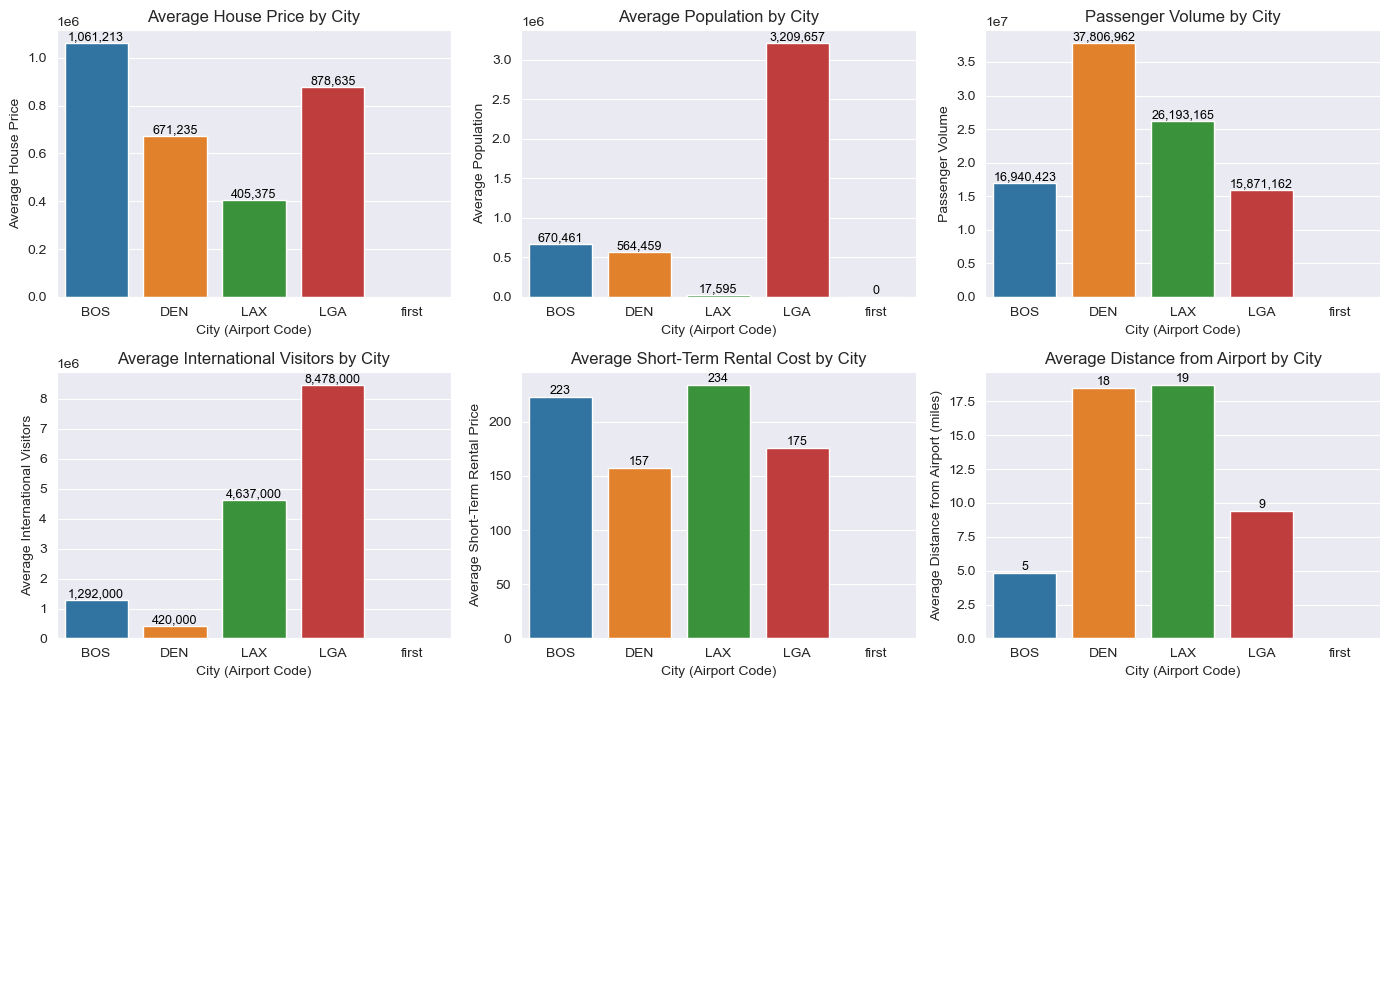

In [67]:
# Show average house prices and short-term rental prices by city (airport_code)
# Now convert to numeric
# Remove duplicate columns
#df = combined_df.loc[:, ~df.columns.duplicated()]
# Convert to numeric if needed
df['house_value'] = pd.to_numeric(df['house_value'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['passengers'] = pd.to_numeric(df['passengers'], errors='coerce')
df['visitors'] = pd.to_numeric(df['visitors'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['distance_from_airport'] = pd.to_numeric(df['distance_from_airport'], errors='coerce')

agg_dict = {
    'house_value': 'mean',
    'population': 'sum',
    'passengers': 'mean',
    'visitors': 'mean',
    'price': 'mean',
    'distance_from_airport': 'mean'
}

city_summary = df.groupby('airport_code').agg(agg_dict).reset_index()
city_summary = city_summary.rename(columns={
    'house_value': 'House Price',
    'population': 'Population',
    'passengers': 'Passenger Volume',
    'visitors': 'International Visitors',
    'price': 'Short-Term Rentals Cost',
    'distance_from_airport': 'Airport Distance'
})


fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# List of (column, title, ylabel, subplot)
plots = [
    ('House Price', 'Average House Price by City', 'Average House Price', axes[0, 0]),
    ('Population', 'Average Population by City', 'Average Population', axes[0, 1]),
    ('Passenger Volume', 'Passenger Volume by City', 'Passenger Volume', axes[0, 2]),
    ('International Visitors', 'Average International Visitors by City', 'Average International Visitors', axes[1, 0]),
    ('Short-Term Rentals Cost', 'Average Short-Term Rental Cost by City', 'Average Short-Term Rental Price', axes[1, 1]),
    ('Airport Distance', 'Average Distance from Airport by City', 'Average Distance from Airport (miles)', axes[1, 2])
]

for col, title, ylabel, ax in plots:
    sns.barplot(x='airport_code', y=col, data=city_summary, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('City (Airport Code)')
    ax.set_ylabel(ylabel)
    # Add value labels on each bar
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(f'{value:,.0f}', 
                    (p.get_x() + p.get_width() / 2., value), 
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

# Hide unused subplots
for i in range(2, 3):
    for j in range(0, 3):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


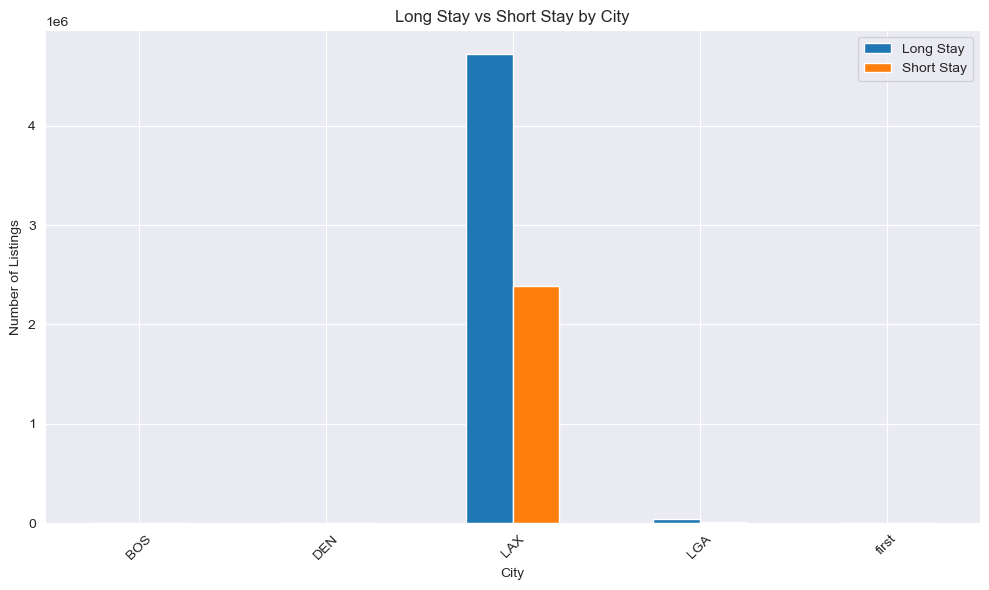

In [64]:
stay_counts = df.groupby("airport_code")[["long_stay", "short_stay"]].sum()
stay_counts.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Long Stay vs Short Stay by City')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.legend(["Long Stay", "Short Stay"])
plt.tight_layout()
plt.show()

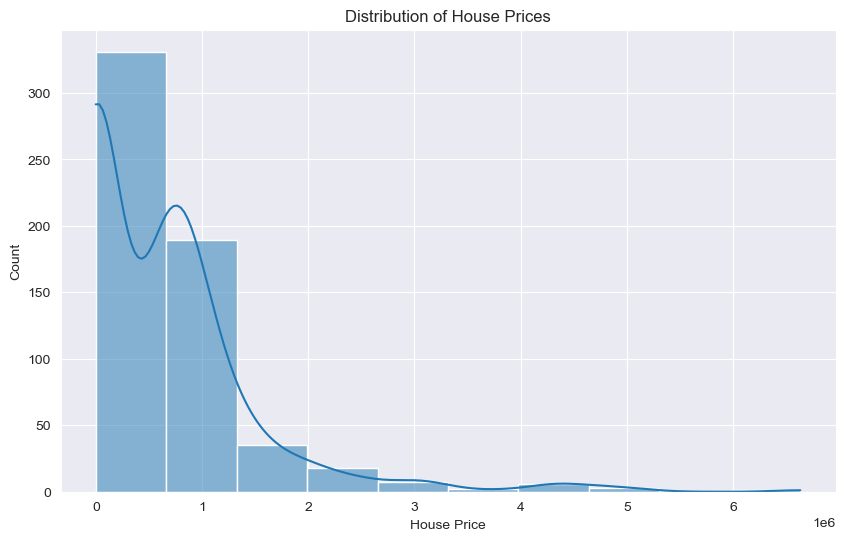

In [11]:
# ---------------------------------------------
# 📈 Visualize Distribution of House Prices
# ---------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df['house_value'], bins=10, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Count')
plt.show()

In [12]:
# short Term Rental Impact on House Prices
plt.figure(figsize=(10, 6))
sns.boxplot(x='long_stay', y='price', data=combined_df)
plt.title('House Price by Short-Term vs Long-Term Rentals')
plt.xlabel('Long Stay')
plt.ylabel('Price')
plt.show()

ValueError: Could not interpret input 'long_stay'

<Figure size 1000x600 with 0 Axes>

In [159]:
# Drop the first row with summary text labels
df = combined_df
df = df.drop(index=0).reset_index(drop=True)

# Convert categorical columns
cat_cols = ['neighbourhood', 'airport_code']
for col in cat_cols:
    df[col] = df[col].astype(str)




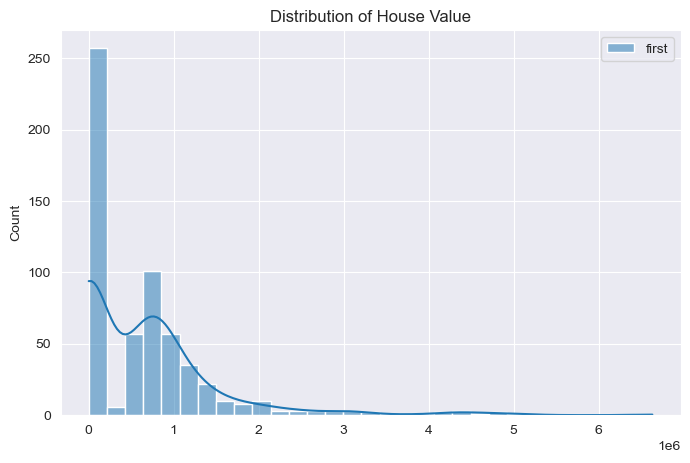

In [160]:
# Exploratory Data Analysis

plt.figure(figsize=(8, 5))
sns.histplot(df['house_value'], kde=True)
plt.title('Distribution of House Value')
plt.show()

In [30]:
display(combined_df[['price', 'availability_365', 'minimum_nights', 'reviews_per_month', 'number_of_reviews_ltm']].describe())          

In [35]:

valid_house_values = pd.to_numeric(combined_df['house_value'], errors='coerce').dropna()

if len(valid_house_values) > 1:
    plt.figure(figsize=(8,4))
    sns.histplot(valid_house_values, bins=30, kde=True)
    plt.title('Distribution of House Prices')
    plt.xlabel('House Value')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("Not enough valid data to plot house price distribution.")

In [32]:

# 2. Distribution of house prices
plt.figure(figsize=(8,4))
sns.histplot(combined_df['house_value'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('House Value')
plt.ylabel('Frequency')
plt.show()

In [31]:

# Convert house_value to numeric if needed
combined_df['house_value'] = pd.to_numeric(combined_df['house_value'], errors='coerce')

# 1. Summary statistics
display(combined_df[['price', 'distance_from_airport', 'population', 'house_value']].describe())

# 2. Distribution of house prices
plt.figure(figsize=(8,4))
sns.histplot(combined_df['house_value'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('House Value')
plt.ylabel('Frequency')
plt.show()

# 3. Boxplot: House price by city (airport_code)
plt.figure(figsize=(8,4))
sns.boxplot(x='airport_code', y='house_value', data=combined_df)
plt.title('House Price by City')
plt.xlabel('Airport Code')
plt.ylabel('House Value')
plt.show()

# 4. Scatter: Distance from airport vs house price
plt.figure(figsize=(8,4))
sns.scatterplot(x='distance_from_airport', y='house_value', hue='airport_code', data=combined_df)
plt.title('Distance from Airport vs House Price')
plt.xlabel('Distance from Airport (miles)')
plt.ylabel('House Value')
plt.show()

# 5. Scatter: Population vs house price
plt.figure(figsize=(8,4))
sns.scatterplot(x='population', y='house_value', hue='airport_code', data=combined_df)
plt.title('Population vs House Price')
plt.xlabel('Population')
plt.ylabel('House Value')
plt.show()

# 6. Hexbin: Short term rental price vs house price
plt.figure(figsize=(8,4))
plt.hexbin(combined_df['price'], combined_df['house_value'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(label='Count')
plt.title('Short Term Rental Price vs House Price')
plt.xlabel('Short Term Rental Price')
plt.ylabel('House Value')
plt.show()

# 7. Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(combined_df[['price', 'distance_from_airport', 'population', 'house_value']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()